[Schema] continuous=9 | categoricals=47


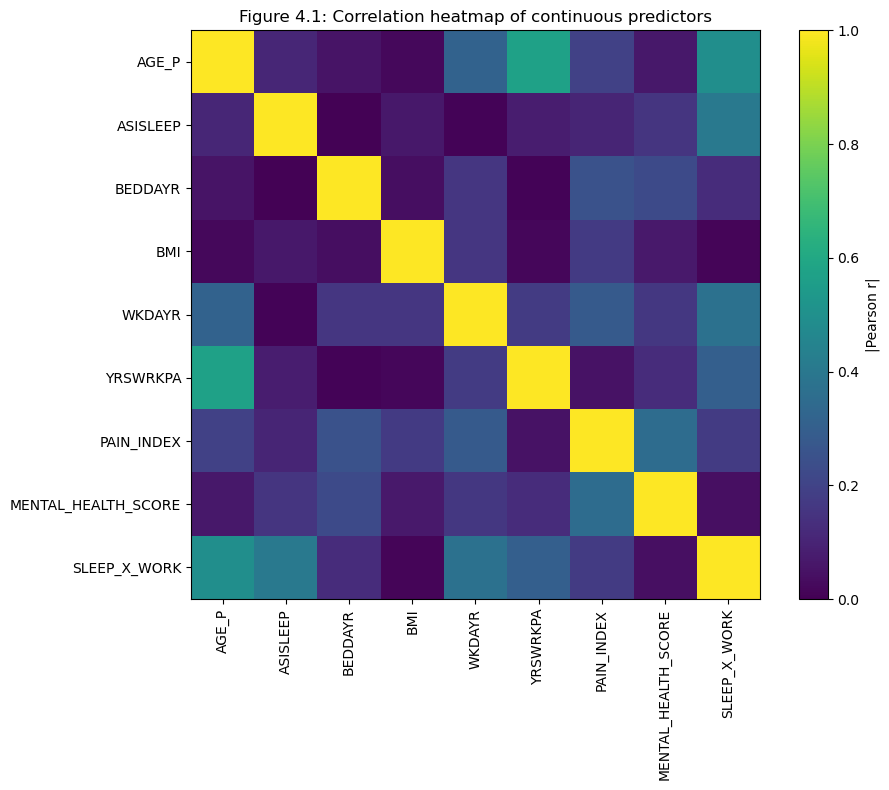

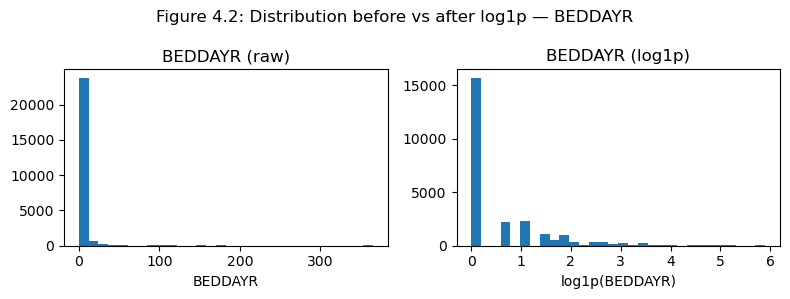

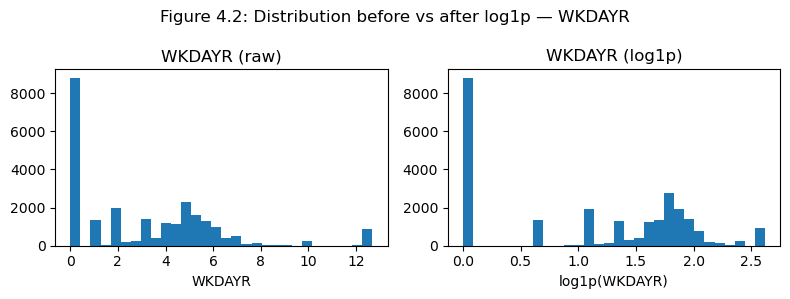

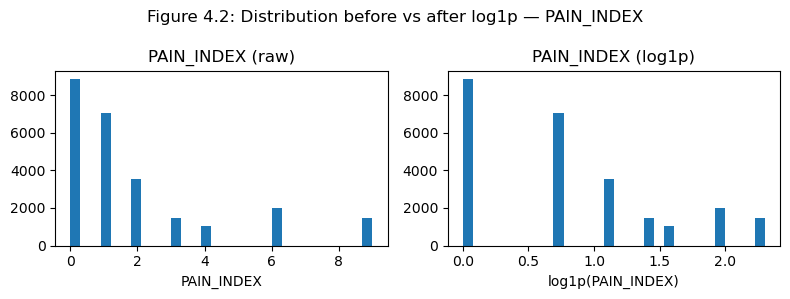

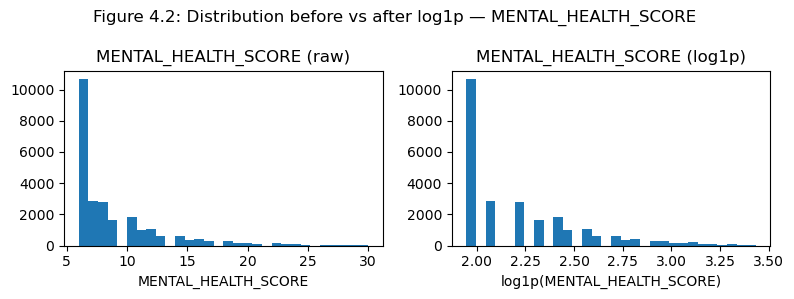

[Transform] log1p applied to: ['BEDDAYR', 'WKDAYR', 'PAIN_INDEX', 'MENTAL_HEALTH_SCORE']
[Transform] z-scored columns: ['AGE_P', 'ASISLEEP', 'BEDDAYR', 'BMI', 'WKDAYR', 'YRSWRKPA', 'PAIN_INDEX', 'MENTAL_HEALTH_SCORE', 'SLEEP_X_WORK'] 
[Encode] One-hot on 47 columns -> final cols: 124

[OK] Saved transformed table -> prep_outputs/final_transformed_table.csv | shape: (25403, 124)
[OK] Saved transformation summary -> prep_outputs/transformation_summary.csv


In [1]:
# =========================================
# 4. Data Transformation (feature reduction + re-expression)
# Inputs:
#   prep_outputs/final_modeling_table_reformatted.csv  (step 3.5 output, no *_LABEL)
# Outputs:
#   prep_outputs/final_transformed_table.csv
#   prep_outputs/transformation_summary.csv
#   figs/fig_4_*.png
# Notes:
#   - Horizontal reduction: drop highly-correlated and near-constant features
#   - Projection: log-transform skewed variables, standardize continuous, one-hot categoricals
# =========================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
os.makedirs("prep_outputs", exist_ok=True)
os.makedirs("figs", exist_ok=True)

IN  = "prep_outputs/final_modeling_table_reformatted.csv"
OUT = "prep_outputs/final_transformed_table.csv"
SUM = "prep_outputs/transformation_summary.csv"

assert os.path.exists(IN), f"Input not found: {IN}"
df0 = pd.read_csv(IN)

RID_COL    = "RID"
TARGET_COL = "AMIGR"

# -----------------------------
# 0) Split schema
# -----------------------------
# Treat strictly-numeric columns as candidates for "continuous",
# but keep a whitelist of integer-coded variables that are categorical.
known_continuous = {
    "AGE_P","BMI","ASISLEEP","ALC_INTENSITY","PAIN_INDEX","MENTAL_HEALTH_SCORE"
}
int_coded_cats = {
    # constructed / cleaned categoricals
    "AGE_BAND","BMI_CAT","WORK_EXP_CAT",
    # binary / code-like
    "SLEEP_SUFFICIENT","SEX","REGION","R_MARITL","HISPAN_I","RACERPI2",
    "ALCSTAT","DOINGLWA","WRKLYR4"
}

# Identify categoricals by dtype or low-cardinality integers
cat_cols = set(c for c in df0.columns
               if c not in {RID_COL, TARGET_COL}
               and (
                   c in int_coded_cats
                   or df0[c].dtype == "object"
                   or (pd.api.types.is_integer_dtype(df0[c]) and df0[c].nunique(dropna=True) <= 20 and c not in known_continuous)
               ))

cont_cols = [c for c in df0.columns
             if c not in {RID_COL, TARGET_COL} and c not in cat_cols
             and pd.api.types.is_numeric_dtype(df0[c])]

print(f"[Schema] continuous={len(cont_cols)} | categoricals={len(cat_cols)}")

# Work on a copy
df = df0.copy()

# -----------------------------
# 1) Horizontal reduction
# -----------------------------
dropped_low_var = []
for c in cont_cols.copy():
    s = df[c]
    # near-constant: one value covers >=95%
    top_prop = s.value_counts(normalize=True, dropna=False).iloc[0]
    if top_prop >= 0.95:
        dropped_low_var.append(c)
        cont_cols.remove(c)

if dropped_low_var:
    print("[Reduce] Dropping near-constant:", dropped_low_var)
    df.drop(columns=dropped_low_var, inplace=True)

# Correlation-based removal (|r| >= 0.85)
corr_thr = 0.85
if cont_cols:
    corr = df[cont_cols].corr(numeric_only=True).abs()
    # plot heatmap for report
    plt.figure(figsize=(10,8))
    plt.imshow(corr, cmap="viridis", vmin=0, vmax=1)
    plt.colorbar(label="|Pearson r|")
    plt.xticks(range(len(cont_cols)), cont_cols, rotation=90)
    plt.yticks(range(len(cont_cols)), cont_cols)
    plt.title("Figure 4.1: Correlation heatmap of continuous predictors")
    plt.tight_layout()
    plt.savefig("figs/fig_4_1_corr_heatmap.png", dpi=200)
    plt.show()
    plt.close()

    # greedy drop upper-tri duplicates above threshold
    to_drop = set()
    for i, ci in enumerate(cont_cols):
        for j in range(i+1, len(cont_cols)):
            cj = cont_cols[j]
            if corr.iloc[i, j] >= corr_thr:
                # keep the one that is "preferred" (domain-important)
                keep = ci if (ci in known_continuous) else cj if (cj in known_continuous) else ci
                drop = cj if keep == ci else ci
                to_drop.add(drop)

    if to_drop:
        print(f"[Reduce] Dropping high-correlation (|r|>={corr_thr}): {sorted(to_drop)}")
        df.drop(columns=list(to_drop), inplace=True)
        cont_cols = [c for c in cont_cols if c not in to_drop]

# -----------------------------
# 2) Projection: log for skewed columns
# -----------------------------
# heuristic: skewness > 1 and all values >= 0
skewed = []
for c in cont_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    if (s.min() >= 0) and (abs(s.skew(skipna=True)) > 1):
        skewed.append(c)

log_cols = []
for c in skewed:
    # create before/after plot (for two typical variables we save figures individually)
    s = pd.to_numeric(df[c], errors="coerce")
    if s.notna().sum() == 0:
        continue
    # save a small figure for report
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1); plt.hist(s, bins=30); plt.title(f"{c} (raw)"); plt.xlabel(c)
    s_log = np.log1p(s)
    plt.subplot(1,2,2); plt.hist(s_log, bins=30); plt.title(f"{c} (log1p)"); plt.xlabel(f"log1p({c})")
    plt.suptitle(f"Figure 4.2: Distribution before vs after log1p — {c}")
    plt.tight_layout()
    plt.savefig(f"figs/fig_4_2_{c.lower()}_log.png", dpi=200)
    plt.show()
    plt.close()

    # replace with log1p in modeling table
    df[c] = s_log
    log_cols.append(c)

if log_cols:
    print("[Transform] log1p applied to:", log_cols)

# -----------------------------
# 3) Standardize continuous (z-score)
# -----------------------------
z_cols = []
for c in cont_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    mu, sd = s.mean(), s.std(ddof=0)
    if np.isfinite(mu) and np.isfinite(sd) and sd > 0:
        df[c] = (s - mu) / sd
        z_cols.append(c)

print("[Transform] z-scored columns:", z_cols[:10], ("..." if len(z_cols) > 10 else ""))

# -----------------------------
# 4) One-hot encode categoricals
# -----------------------------
# keep RID & TARGET, one-hot the rest (drop_first to avoid full dummy trap)
base_cols = [c for c in df.columns if c not in {RID_COL, TARGET_COL}]
cat_cols_present = [c for c in cat_cols if c in df.columns]

df_model = pd.get_dummies(
    df[[RID_COL, TARGET_COL] + base_cols],
    columns=cat_cols_present,
    drop_first=True,
    dtype=float
)

print(f"[Encode] One-hot on {len(cat_cols_present)} columns -> final cols: {df_model.shape[1]}")

# -----------------------------
# 5) QA & Save
# -----------------------------
summary = {
    "dropped_low_variance": dropped_low_var,
    "log_transformed": log_cols,
    "standardized": z_cols,
    "one_hot_columns": cat_cols_present
}
pd.DataFrame(
    [(k, json.dumps(v)) for k,v in summary.items()],
    columns=["item", "value_json"]
).to_csv(SUM, index=False)

df_model.to_csv(OUT, index=False)

print("\n[OK] Saved transformed table ->", OUT, "| shape:", df_model.shape)
print("[OK] Saved transformation summary ->", SUM)


In [2]:
# =========================================
# Feature Selection (MI + L1 Logistic, union)
# Requires:
#   - df_model : one-hot encoded table that still contains RID and AMIGR
# Produces:
#   - prep_outputs/final_transformed_table_selected.csv
#   - prep_outputs/selected_features.json
#   - figs/fig_4_fs_mi_top20.png
#   - figs/fig_4_fs_l1_top20.png
# =========================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV

FS_OUT  = "prep_outputs/final_transformed_table_selected.csv"
FS_LIST = "prep_outputs/selected_features.json"

# ---- 0) Build feature matrix (X) and target (y); NEVER use RID as a predictor
assert RID_COL in df_model.columns and TARGET_COL in df_model.columns, "RID/AMIGR missing."
X = df_model.drop(columns=[RID_COL, TARGET_COL]).copy()
y = df_model[TARGET_COL].astype(int).values

# ---- 1) Filter by Mutual Information (non-parametric, handles non-linear signals)
# Keep either top 40% or cap at 80 features (whichever is smaller but at least 10)
k_cap  = 80
k_prop = 0.40
k = min(k_cap, max(10, int(k_prop * X.shape[1])))

mi_sel = SelectKBest(score_func=mutual_info_classif, k=k)
mi_sel.fit(X, y)
mi_mask   = mi_sel.get_support()
mi_scores = pd.Series(mi_sel.scores_, index=X.columns).fillna(0).sort_values(ascending=False)

# Plot top-20 MI features
top20_mi = mi_scores.head(20)
plt.figure(figsize=(8,5))
top20_mi.iloc[::-1].plot(kind="barh")
plt.title("Top-20 features by Mutual Information")
plt.tight_layout()
plt.savefig("figs/fig_4_fs_mi_top20.png", dpi=200)
plt.close()

# ---- 2) Embedded selection with L1-regularized Logistic Regression
# Tune C via 5-fold CV for a reasonably sparse-yet-predictive model
param_grid = {"C": [0.05, 0.1, 0.2, 0.5, 1.0]}
base_lr = LogisticRegression(
    penalty="l1", solver="liblinear", max_iter=200, class_weight="balanced"
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(base_lr, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
grid.fit(X, y)
best_lr = grid.best_estimator_

# Non-zero coefficients are selected
coef_abs = pd.Series(np.abs(best_lr.coef_).ravel(), index=X.columns)
l1_mask  = coef_abs > 0

# Plot top-20 by absolute coefficient magnitude
top20_l1 = coef_abs.sort_values(ascending=False).head(20)
plt.figure(figsize=(8,5))
top20_l1.iloc[::-1].plot(kind="barh")
plt.title("Top-20 features by |L1 coefficient|")
plt.tight_layout()
plt.savefig("figs/fig_4_fs_l1_top20.png", dpi=200)
plt.close()

# ---- 3) Union strategy for stability and recall (can switch to intersection if desired)
keep_cols = sorted(list(set(X.columns[mi_mask]) | set(X.columns[l1_mask])))
print(f"[FS] MI kept: {mi_mask.sum()} | L1 kept: {l1_mask.sum()} | Union: {len(keep_cols)}")

# Final selected table (keep RID and AMIGR for traceability and evaluation)
df_fs = pd.concat([df_model[[RID_COL, TARGET_COL]], X[keep_cols]], axis=1)
df_fs.to_csv(FS_OUT, index=False)

with open(FS_LIST, "w") as f:
    json.dump({
        "mi_top_k": int(k),
        "mi_kept": X.columns[mi_mask].tolist(),
        "l1_best_C": grid.best_params_["C"],
        "l1_kept": X.columns[l1_mask].tolist(),
        "union_kept": keep_cols
    }, f, indent=2)

print(f"[OK] Feature selection saved -> {FS_OUT} | shape: {df_fs.shape}")
print(f"[OK] Feature lists saved    -> {FS_LIST}")


[FS] MI kept: 48 | L1 kept: 71 | Union: 83
[OK] Feature selection saved -> prep_outputs/final_transformed_table_selected.csv | shape: (25403, 85)
[OK] Feature lists saved    -> prep_outputs/selected_features.json
